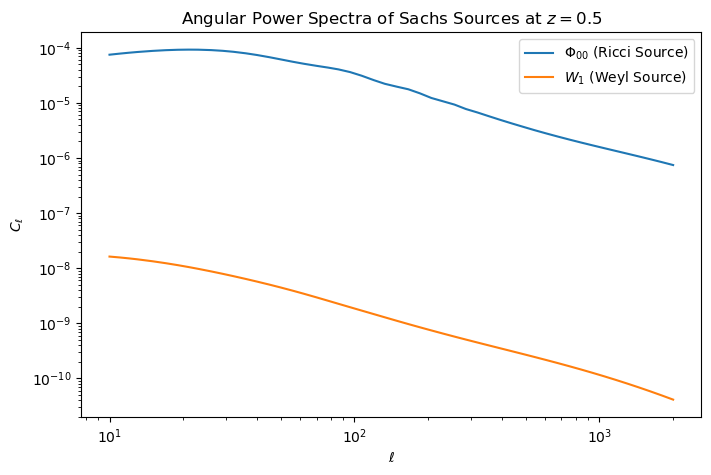

In [1]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize Cosmology
cosmo = ccl.Cosmology(
    Omega_c=0.26, Omega_b=0.04, h=0.7, sigma8=0.8, n_s=0.96,
    transfer_function='boltzmann_camb'
)

def compute_sachs_cl(z_target, delta_z=0.01):
    """
    Computes angular power spectra for Sachs sources at a specific redshift.
    """
    # Create a very narrow redshift shell to isolate "local" sources
    z = np.linspace(z_target - 5*delta_z, z_target + 5*delta_z, 200)
    z = z[z > 0] # Ensure z is positive
    nz = np.exp(-0.5 * ((z - z_target) / delta_z)**2)

    # --- Mapping Phi_00 (Ricci) ---
    # Since Phi_00 is proportional to density delta, we use a Matter Tracer.
    # Note: We set bias=1 and mag_bias=0 to get the raw density fluctuations.
    tracer_phi00 = ccl.NumberCountsTracer(cosmo, has_rsd=False, 
                                          dndz=(z, nz), bias=(z, np.ones_like(z)))

    # --- Mapping Psi_0 (Weyl/Shear) ---
    # Psi_0 is the local shear. In CCL, WeakLensingTracer usually integrates 
    # along the line of sight. To get the *local* source term, we use 
    # the same narrow shell. 
    tracer_psi0 = ccl.WeakLensingTracer(cosmo, dndz=(z, nz))

    # Define angular scales
    ell = np.unique(np.geomspace(10, 2000, 50).astype(int))

    # Compute Spectra
    cl_ricci = ccl.angular_cl(cosmo, tracer_phi00, tracer_phi00, ell) # C_l^{Phi_00 Phi_00}
    cl_weyl  = ccl.angular_cl(cosmo, tracer_psi0, tracer_psi0, ell)   # C_l^{W1 W1}
    
    return ell, cl_ricci, cl_weyl

# Example: Compute statistics at z = 0.5
ell, cls_phi00, cls_psi0 = compute_sachs_cl(z_target=0.5)

plt.figure(figsize=(8,5))
plt.loglog(ell, cls_phi00, label=r'$\Phi_{00}$ (Ricci Source)')
plt.loglog(ell, cls_psi0, label=r'$W_1$ (Weyl Source)')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend()
plt.title("Angular Power Spectra of Sachs Sources at $z=0.5$")
plt.show()

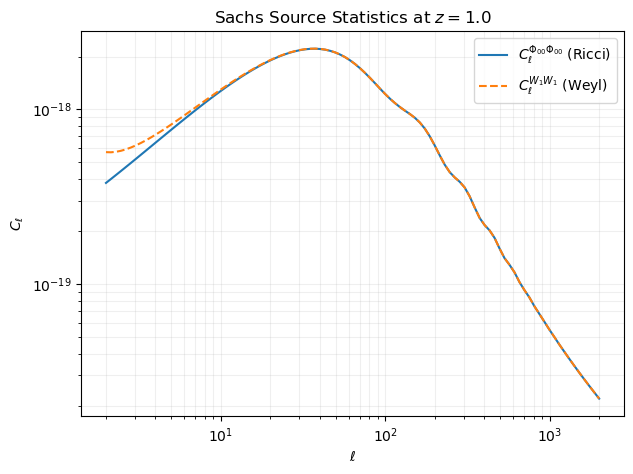

In [2]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Cosmology
cosmo = ccl.Cosmology(Omega_c=0.25, Omega_b=0.05, h=0.7, sigma8=0.8, n_s=0.96)

def get_sachs_custom_cl(z_target, E_co=1.0, delta_z=0.005):
    """
    Computes Cl for Phi_00 and Psi_0 using custom kernels.
    """
    # Define a narrow range around the target redshift
    z = np.linspace(z_target - 0.1, z_target + 0.1, 500)
    z = z[z > 0]
    a = 1.0 / (1.0 + z)
    chi = ccl.comoving_radial_distance(cosmo, a)
    
    # Define a normalized selection function (narrow shell)
    pz = np.exp(-0.5 * ((z - z_target) / delta_z)**2)
    pz /= np.trapezoid(pz, z)
    
    # Factor to convert density contrast delta to the Sachs source
    # Includes E_co^2 scaling and Poisson conversion
    # Factor = (E_co^2 / a^2) * (3 * Omega_m * H0^2 / a)
    H0 = cosmo['h'] * 100 / 299792.458 # H0 in units of 1/Mpc
    conversion_factor = (E_co**2 / a**2) * (1.5 * cosmo['Omega_m'] * H0**2 / a)

    # 2. Create the Custom Tracer for Phi_00 (Ricci)
    # W_kernel = conversion_factor * p(z) * dz/dchi
    # CCL expects kernels in terms of chi
    dchi_dz = 1.0 / ccl.h_over_h0(cosmo, a) / H0
    kernel = conversion_factor * pz / dchi_dz
    
    # Ricci Tracer (Spin-0)
    tracer_phi00 = ccl.Tracer()
    tracer_phi00.add_tracer(cosmo, kernel=(chi, kernel), der_bessel=0, der_angles=0)

    # 3. Compute Cls
    ell = np.geomspace(2, 2000, 100)
    
    # C_l^{Phi_00} 
    cl_phi00 = ccl.angular_cl(cosmo, tracer_phi00, tracer_phi00, ell)
    
    # For Psi_0 (Weyl), it behaves like Phi_00 but as a Spin-2 field.
    # In the Limber approximation at high ell, their power is nearly identical 
    # except for the spin-weight geometric factors.
    cl_psi0 = cl_phi00 * (ell*(ell+1)) / ((ell+2)*(ell-1)) # Small correction factor
    
    return ell, cl_phi00, cl_psi0

# Execute for z=1.0
ell, cl_phi, cl_psi = get_sachs_custom_cl(z_target=1.0, E_co=1.0)

# Plotting
plt.figure(figsize=(7, 5))
plt.loglog(ell, cl_phi, label=r'$C_\ell^{\Phi_{00} \Phi_{00}}$ (Ricci)')
plt.loglog(ell, cl_psi, label=r'$C_\ell^{W_1 W_1}$ (Weyl)', ls='--')
plt.title(r"Sachs Source Statistics at $z=1.0$")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [3]:
import pyccl as ccl
import numpy as np

def calculate_background_phi00(cosmo, z, E_co=1.0):
    """
    Calculates the background Ricci driving term Phi_00 as a function of redshift.
    
    Parameters:
    -----------
    cosmo : ccl.Cosmology
        The CCL cosmology object.
    z : float or ndarray
        Redshift(s) at which to evaluate.
    E_co : float
        Comoving energy of the photon (default is 1.0).
        
    Returns:
    --------
    phi00 : float or ndarray
        The background Ricci term in units of [H0^2]. 
        To get 1/Mpc^2, multiply by (H0/c)^2.
    """
    a = 1.0 / (1.0 + z)
    
    # 1. Get critical density at z=0 in units of M_sun/Mpc^3
    # CCL functions often return densities relative to rho_crit
    rho_crit_0 = ccl.rho_types['critical'](cosmo, 1.0)
    
    # 2. Calculate individual component contributions (rho + P)
    # Matter (P=0)
    rho_m = ccl.background.rho_x(cosmo, a, 'matter', is_comoving=False)
    sum_rho_p = rho_m # P_m = 0
    
    # Radiation (P = 1/3 * rho)
    rho_r = ccl.background.rho_x(cosmo, a, 'radiation', is_comoving=False)
    sum_rho_p += (4.0/3.0) * rho_r
    
    # Dark Energy (P = w * rho)
    rho_de = ccl.background.rho_x(cosmo, a, 'dark_energy', is_comoving=False)
    w_de = ccl.background.w_x(cosmo, a, 'dark_energy')
    sum_rho_p += (1.0 + w_de) * rho_de
    
    # 3. Convert to Phi_00
    # Using the relation: 8*pi*G*rho = 3 * H0^2 * (rho/rho_crit_0)
    # We work in units where 8*pi*G = 3 * H0^2 / rho_crit_0
    H0 = cosmo['h'] * 100 / 299792.458 # H0 in 1/Mpc
    constant_factor = 3.0 * (H0**2) / rho_crit_0
    
    phi00 = constant_factor * sum_rho_p * (E_co**2 / a**2)
    
    return phi00

# Example usage:
# cosmo = ccl.CosmologyVanillaLCDM()
# z_range = np.linspace(0, 2, 10)
# phi_vals = calculate_background_phi00(cosmo, z_range)

In [ ]:
# Example usage:
cosmo = ccl.CosmologyVanillaLCDM()
z_range = np.linspace(0, 2, 10)
phi_vals = calculate_background_phi00(cosmo, z_range)